## Questão 2


In [8]:
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem.lancaster import LancasterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/bearodrigues/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/bearodrigues/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/bearodrigues/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
stop_words = set(stopwords.words("english"))
stemmer = LancasterStemmer()

def preprocess_lyrics(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"\b\w*\d\w*\b", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = nltk.word_tokenize(text)
    stems = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(stems)

In [10]:
df = pd.read_csv("data/songs_reduced.csv")
df["preprocessed_lyrics"] = df["lyrics"].apply(preprocess_lyrics)

X_text = df["preprocessed_lyrics"]
y = df["genre"]

### a) Rótulo dos documentos

A base já possui uma coluna `genre`, que será usada como rótulo do problema de classificação. Ela divide as músicas em 5 classes bem definidas e perfeitamente balanceadas.

In [11]:
df["genre"].value_counts()

genre
Hip-Hop    4000
Country    4000
Pop        4000
Rock       4000
Folk       4000
Name: count, dtype: int64

### b) Representações vetoriais

Os textos pré-processados (mesma limpeza usada na primeira lista: minúsculas, remoção de palavras com dígitos, remoção de pontuação, tokenização, remoção de stopwords e stemização) são vetorizados com `CountVectorizer` e `TfidfVectorizer`. Em ambos, `min_df=10` remove tokens muito raros (provável ruído/erros de digitação) e `max_df=0.9` remove tokens presentes em quase todos os documentos, reduzindo o vocabulário e o custo computacional sem descaracterizar o conteúdo.

In [12]:
count_vectorizer = CountVectorizer(max_df=0.9, min_df=10)
X_count = count_vectorizer.fit_transform(X_text)

tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=10)
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print("CountVectorizer:", X_count.shape)
print("TfidfVectorizer:", X_tfidf.shape)

CountVectorizer: (20000, 8050)
TfidfVectorizer: (20000, 8050)


### c) Treino e avaliação

Foram escolhidos três classificadores: Regressão Logística, Naive Bayes (Multinomial) e SVM linear (`LinearSVC`). Os três lidam bem com matrizes esparsas de alta dimensão, típicas de representações de texto, sendo baselines padrão da literatura para esse tipo de problema — diferente de k-NN e Random Forest, que tendem a sofrer mais com a maldição da dimensionalidade nesse cenário.

Cada classificador é treinado em cima das duas representações vetoriais (CountVectorizer e TF-IDF), usando um split estratificado de 70% treino / 30% teste.

In [13]:
Xc_train, Xc_test, y_train, y_test = train_test_split(
    X_count, y, test_size=0.3, stratify=y, random_state=42
)
Xt_train, Xt_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.3, stratify=y, random_state=42
)

In [14]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision_micro = precision_score(y_test, y_pred, average="micro")
    precision_macro = precision_score(y_test, y_pred, average="macro")
    recall_micro = recall_score(y_test, y_pred, average="micro")
    recall_macro = recall_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"== {label} ==")
    print(f"Acurácia: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
    plt.title(label)
    plt.show()

    return {
        "modelo": label,
        "acuracia": accuracy,
        "precisao_micro": precision_micro,
        "precisao_macro": precision_macro,
        "recall_micro": recall_micro,
        "recall_macro": recall_macro,
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
    }

== Regressão Logística (CountVectorizer) ==
Acurácia: 0.5035
              precision    recall  f1-score   support

     Country       0.52      0.56      0.54      1200
        Folk       0.40      0.40      0.40      1200
     Hip-Hop       0.78      0.75      0.76      1200
         Pop       0.37      0.34      0.35      1200
        Rock       0.45      0.47      0.46      1200

    accuracy                           0.50      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.50      0.50      0.50      6000



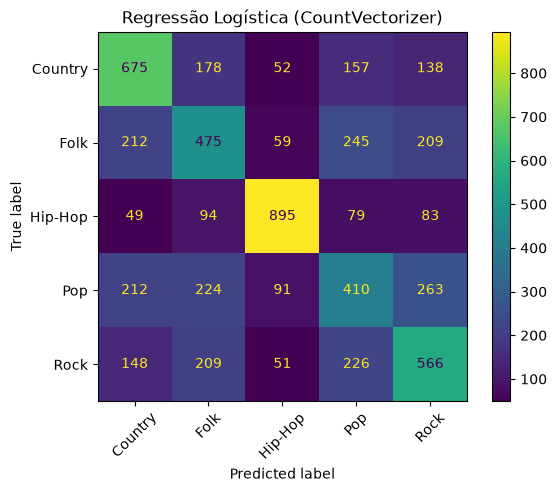

== Naive Bayes (CountVectorizer) ==
Acurácia: 0.5485
              precision    recall  f1-score   support

     Country       0.52      0.64      0.58      1200
        Folk       0.73      0.24      0.36      1200
     Hip-Hop       0.81      0.76      0.79      1200
         Pop       0.40      0.49      0.44      1200
        Rock       0.47      0.61      0.53      1200

    accuracy                           0.55      6000
   macro avg       0.59      0.55      0.54      6000
weighted avg       0.59      0.55      0.54      6000



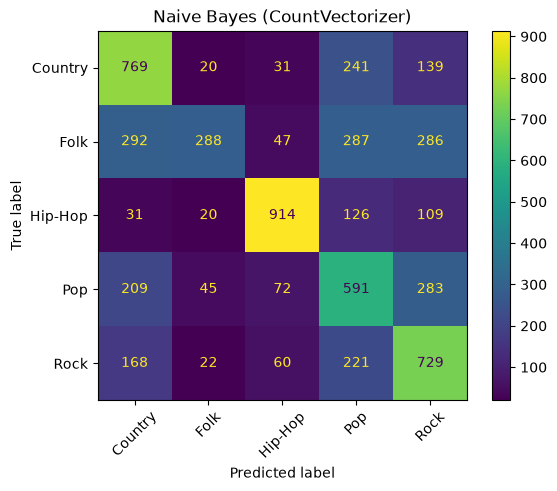

/home/bearodrigues/codes/8p/nlp-numerical-methods/nlp/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


== SVM Linear (CountVectorizer) ==
Acurácia: 0.4968
              precision    recall  f1-score   support

     Country       0.50      0.57      0.53      1200
        Folk       0.40      0.39      0.40      1200
     Hip-Hop       0.76      0.74      0.75      1200
         Pop       0.38      0.33      0.35      1200
        Rock       0.44      0.45      0.44      1200

    accuracy                           0.50      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.50      0.50      0.50      6000



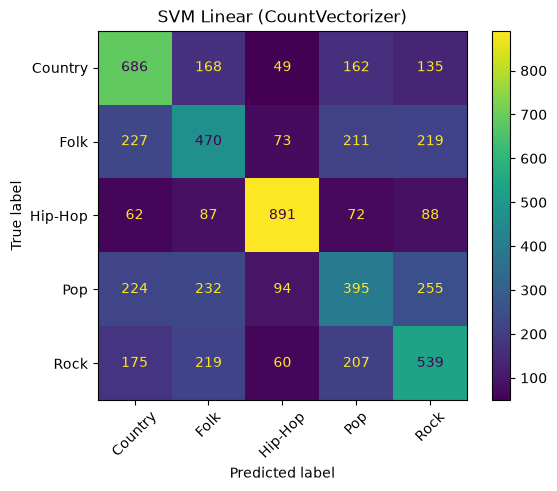

== Regressão Logística (TF-IDF) ==
Acurácia: 0.5648
              precision    recall  f1-score   support

     Country       0.57      0.63      0.60      1200
        Folk       0.48      0.40      0.44      1200
     Hip-Hop       0.83      0.80      0.82      1200
         Pop       0.42      0.44      0.43      1200
        Rock       0.52      0.55      0.54      1200

    accuracy                           0.56      6000
   macro avg       0.57      0.56      0.56      6000
weighted avg       0.57      0.56      0.56      6000



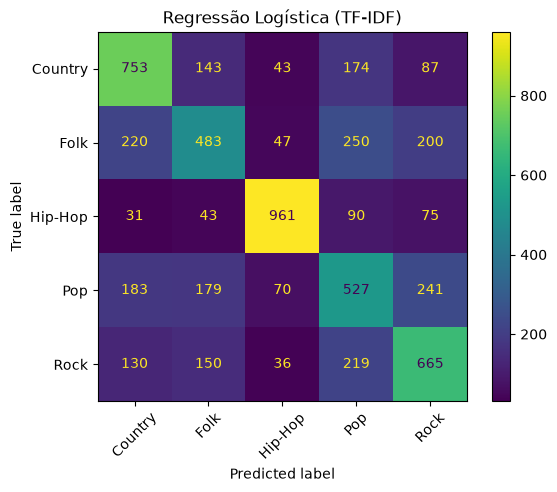

== Naive Bayes (TF-IDF) ==
Acurácia: 0.5605
              precision    recall  f1-score   support

     Country       0.50      0.72      0.59      1200
        Folk       0.62      0.28      0.39      1200
     Hip-Hop       0.80      0.78      0.79      1200
         Pop       0.42      0.48      0.45      1200
        Rock       0.54      0.54      0.54      1200

    accuracy                           0.56      6000
   macro avg       0.58      0.56      0.55      6000
weighted avg       0.58      0.56      0.55      6000



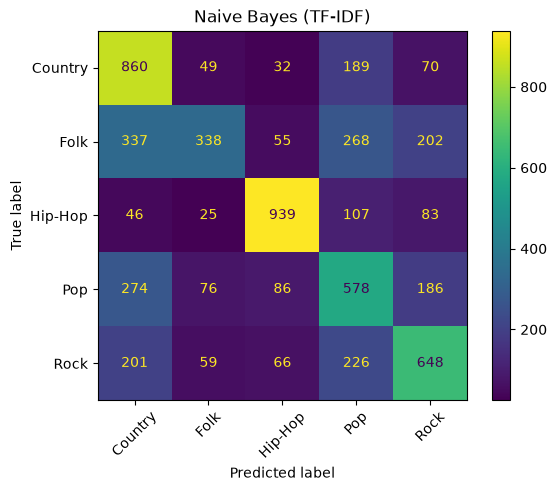

== SVM Linear (TF-IDF) ==
Acurácia: 0.5525
              precision    recall  f1-score   support

     Country       0.56      0.63      0.59      1200
        Folk       0.47      0.40      0.43      1200
     Hip-Hop       0.83      0.80      0.81      1200
         Pop       0.40      0.41      0.41      1200
        Rock       0.50      0.52      0.51      1200

    accuracy                           0.55      6000
   macro avg       0.55      0.55      0.55      6000
weighted avg       0.55      0.55      0.55      6000



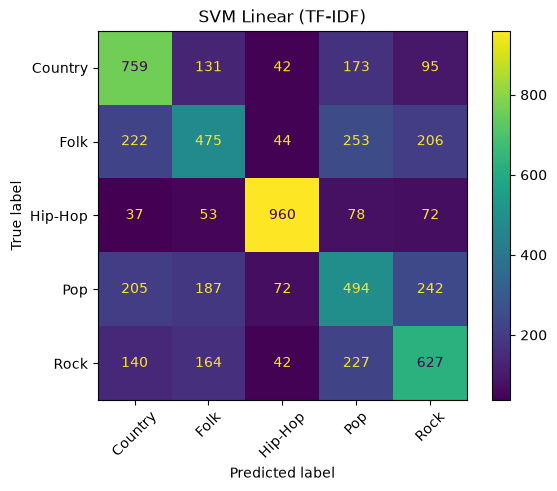

In [15]:
classifiers = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM Linear": LinearSVC(),
}

results = []

for name, model in classifiers.items():
    results.append(
        train_and_evaluate(
            model, Xc_train, Xc_test, y_train, y_test, f"{name} (CountVectorizer)"
        )
    )

for name, model in classifiers.items():
    results.append(
        train_and_evaluate(
            model, Xt_train, Xt_test, y_train, y_test, f"{name} (TF-IDF)"
        )
    )

### d) Comparação dos resultados

In [16]:
results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df

,modelo,acuracia,precisao_micro,precisao_macro,recall_micro,recall_macro,f1_micro,f1_macro
0,Regressão Logística (TF-IDF),0.564833,0.564833,0.565804,0.564833,0.564833,0.564833,0.564124
1,Naive Bayes (TF-IDF),0.560500,0.560500,0.576624,0.560500,0.560500,0.560500,0.551755
2,SVM Linear (TF-IDF),0.552500,0.552500,0.552568,0.552500,0.552500,0.552500,0.551327
3,Naive Bayes (CountVectorizer),0.548500,0.548500,0.588089,0.548500,0.548500,0.548500,0.539653
4,Regressão Logística (CountVectorizer),0.503500,0.503500,0.503922,0.503500,0.503500,0.503500,0.503326
5,SVM Linear (CountVectorizer),0.496833,0.496833,0.495156,0.496833,0.496833,0.496833,0.495121
